# A one dimentional diffusion model

Here # use esc key and then m to convert it ito markdown

Here we develop a one-dimentional model of diffusion
It assumes a constant diffusively.
it uses a regular grid
it has a step function for an initial condition
it has fixed boundary conditions.



The diffusion equation: 
$$ \frac{\partial C}{\partial t} = D\frac{\partial^2 C}{\partial x^2} $$



The discretized version of  the diffusion equation we will solve with our model: 
$$ C^{t+1}_x = C^t_x + {D \Delta t \over \Delta x^2} (C^t_{x+1} - 2C^t_x + C^t_{x-1}) $$

This is the FTCS scheme described in various textbooks. also wikipedia



We will use 2 libraries, Numpy for arrays adn matplotlib for plots, that areanot a part of the core python library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Start by setting two fixed model parameters,
the diffusivity and the size of the model domain.

In [2]:
D = 100
Lx = 300

Next, set up the model grid using a NumPy array.

In [3]:
dx = 0.5 #grid spacing
x = np.arange (start=0, stop=Lx, step=dx) #arrange function
nx = len(x) #how many  bujhay len function 

In [4]:
C = np.zeros_like(x)
C_left = 500
C_right = 0
C[x <= Lx//2] =C_left #c for values of x that are less than half the domain size are set to be on left, // is important
C[x > Lx//2] =C_right

In [5]:
C

array([500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 50

PLOT THE INITIAL CONCENTRATION PROFILE

Text(0.5, 1.0, 'Initial concentration profile')

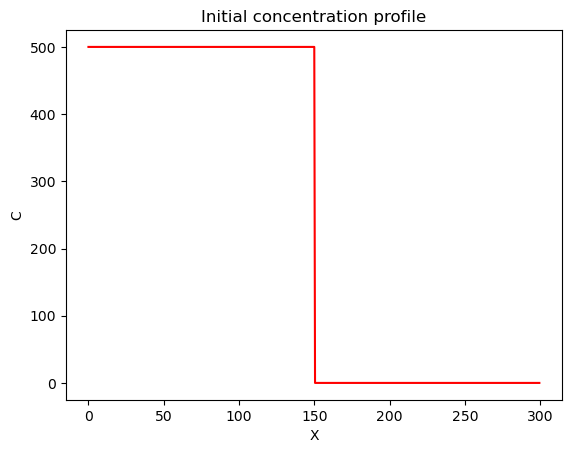

In [6]:
plt.figure()
plt.plot(x, C, "r")
plt.xlabel("X")
plt.ylabel("C")
plt.title("Initial concentration profile")

Set the number of time steps in the model
Calculate a stable time setup using stability criterion

In [7]:
nt = 5000
dt = 0.5 * dx**2/D

In [8]:
dt

0.00125

Loop over the time steps of the model, solving the diffision equation using the FTCS scheme described above.
Note the use of array operations on the concentration `C`.
The boundary conditions remain fixed in each time step.

In [10]:
for t in range (0, nt):
    C[1:-1]+= D * dt/ dx ** 2* (C[:-2] -2*C[1:-1] + C[2:])# dt is time step and dx is grid spacing, C is for concentration, 

plot the result.

Text(0.5, 1.0, 'Final concentration profile')

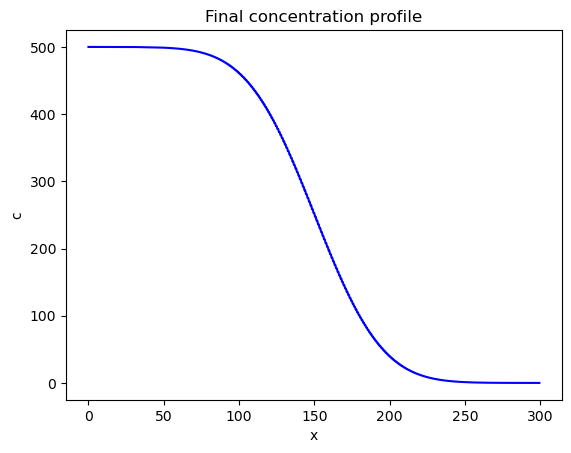

In [11]:
plt.figure()
plt.plot(x, C, "b")
plt.xlabel("x")
plt.ylabel("c")
plt.title("Final concentration profile")